In [105]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path(".") # change to path folder with data 

import matplotlib.pyplot as plt
import seaborn as sns


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

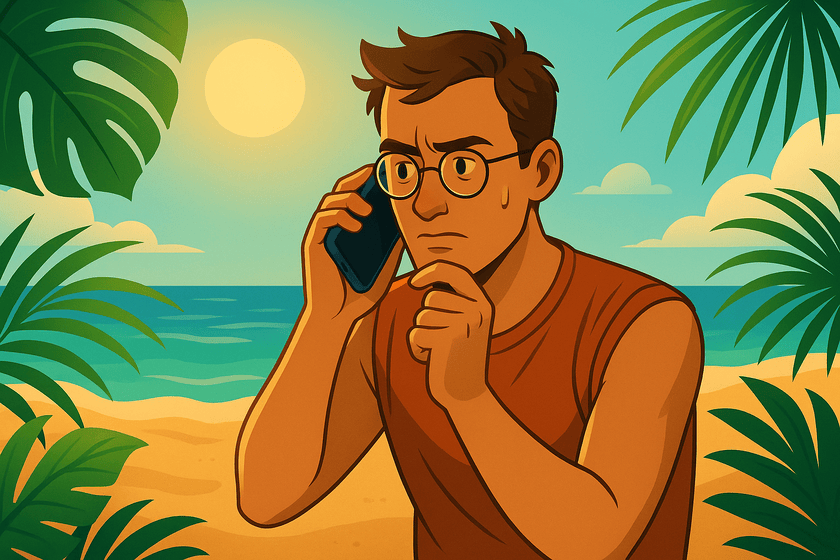

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


# 1. Wczytywanie danych

In [106]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 2. Podstawowe informacje i analiza braków

In [107]:
titanic_df.info() # sprawdzam podstawowe informacje o typach i kolumnach

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [108]:
def get_percentage_missing(df, axis):
    missing_rows = df.isna().sum(axis=axis)
    missing_rows_perc = np.round(missing_rows/df.shape[axis]*100,1)
    return missing_rows_perc[missing_rows_perc > 0]
missing_col = get_percentage_missing(titanic_df,axis=0)
missing_col # sprawdzam analizę procentową brakujących wartości

Age         19.9
Fare        11.0
Cabin       77.1
Embarked     0.2
dtype: float64

**Cabin:** Procent brakujących danych jest 77.1. Utworzymy nową kolumnę `Deck`, gdzie będzie zapisane numer pokłady dla odpowiedniej kabiny.

**Age:** 19.9% brakujących danych. Wypełnimy braki za pomocą mediany na podstawie tytułów.

**Fare:** Uzupełniamy medianą odpowiednie do `Pclass`

**Embarked:** Procent brakujących danych jest bardzo mały (0.2%), więc uzupełniamy dominującej wartością

# 3. Czyszczenie danych 

### 3.1 Wyciągnięcie tytułów

In [109]:
titanic_df['Title'] = titanic_df['Name'].apply(lambda x : x.split(',')[1].split('.')[0].strip()) #Wyciągnięcie tylko tytułów z Name

titanic_df['Title'].value_counts() # Sprawdzenie wszystkich tytułów w Name

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [110]:
mapping = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'the Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare', 
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
titanic_df['Title'] = titanic_df['Title'].replace(mapping)
titanic_df.Title.unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

### 3.2 Uzupełnienie braków 

In [111]:
titanic_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [112]:
# Uzupełnienie brakujących wartości
titanic_df['Age'] = titanic_df.groupby(['Title'])['Age'].transform(lambda x : x.fillna(x.median()))

titanic_df['Fare'] = titanic_df.groupby(['Pclass'])['Fare'].transform(lambda x : x.fillna(x.median()))


titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')


titanic_df[['Age', 'Embarked', 'Fare']].isna().sum() # Sprawdzenie czy wszystkie NaN zostałe zamienione

Age         0
Embarked    0
Fare        0
dtype: int64

In [113]:
titanic_df.dtypes 

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
Title        object
dtype: object

In [114]:
titanic_df['Age'] = titanic_df['Age'].astype(int)

### 3.3 Dodawanie oraz usunięcie kolumn

Na początku trzeba wyciągnąć pokład z `Cabin`

In [115]:
titanic_df['IsCabin'] = titanic_df['Cabin'].notna().astype(int)
titanic_df = titanic_df.drop(columns=['Cabin'])


In [116]:
family_size = titanic_df['Parch'] + titanic_df['SibSp'] + 1
titanic_df['IsAlone']=(family_size==1).astype(int)

titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,IsCabin,IsAlone
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,Mr,0,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,Mrs,1,0
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,Miss,0,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,Mrs,1,0
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,Mr,0,1


Kolumne `Name` i `Ticket` nie są przydatne, ponieważ prawie każdy pasażer ma unikalne wartości w tych kolumnach i da się z tego coś wywnioskować. Dodatkowo usunęłam `Cabin`, ponieważ zrobiłam odrębną klasę `Deck`

In [117]:
titanic_df.drop(columns=['Ticket', 'Name'],inplace=True)

# 4. Wizualizacja danych

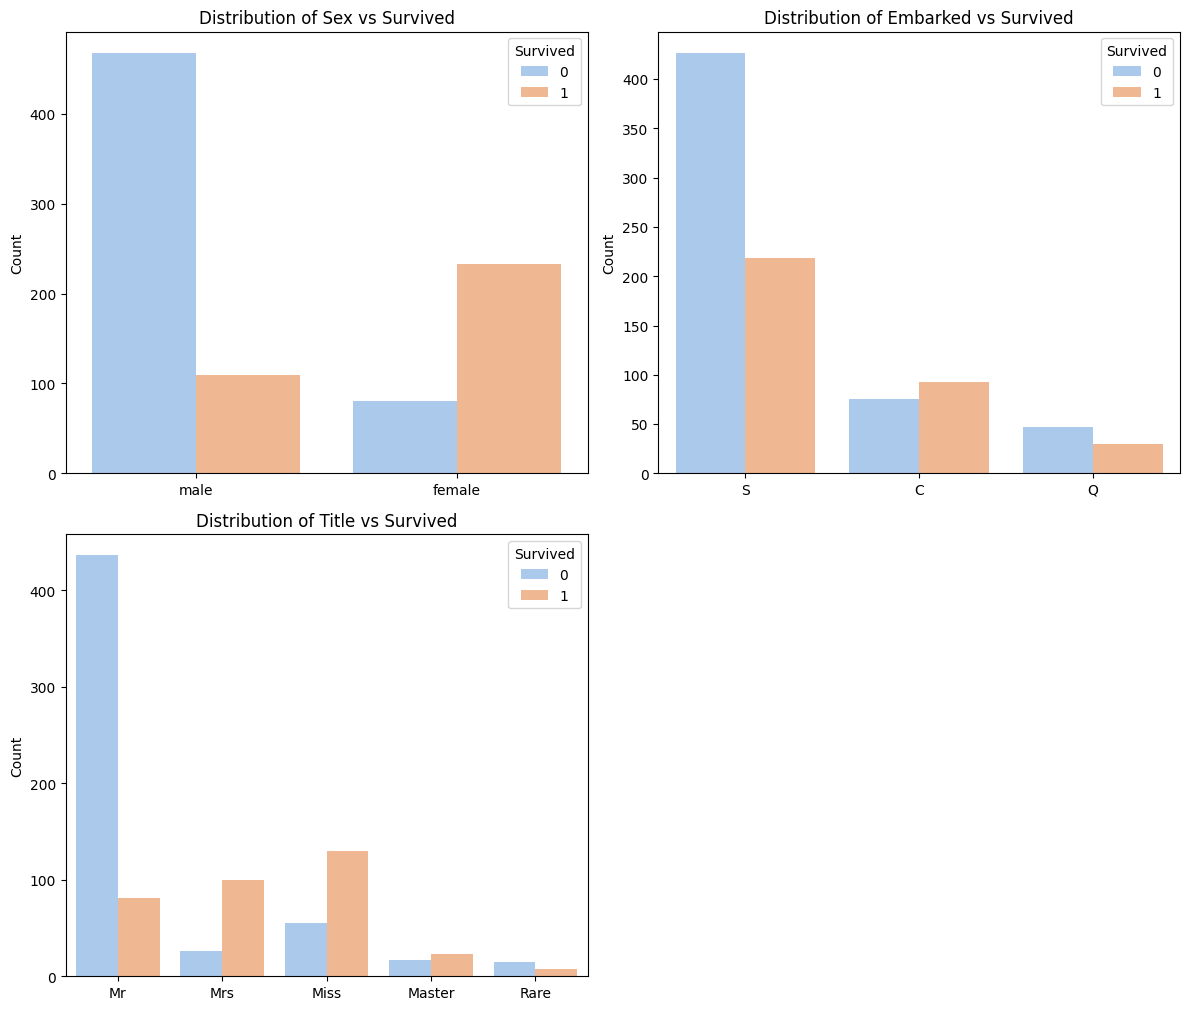

In [118]:
def plot_categorical_distributions(df):
    categorical_columns = df.select_dtypes(include=['object']).columns
    plt.figure(figsize=(2 * 6, 3 * 5))

    for idx, column in enumerate(categorical_columns, 1):
        plt.subplot(3, 2, idx)
        sns.countplot(x=column, hue='Survived', data=df, palette='pastel')
        plt.title(f'Distribution of {column} vs Survived')
        plt.xlabel('')
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()


plot_categorical_distributions(titanic_df)

<Figure size 600x400 with 0 Axes>

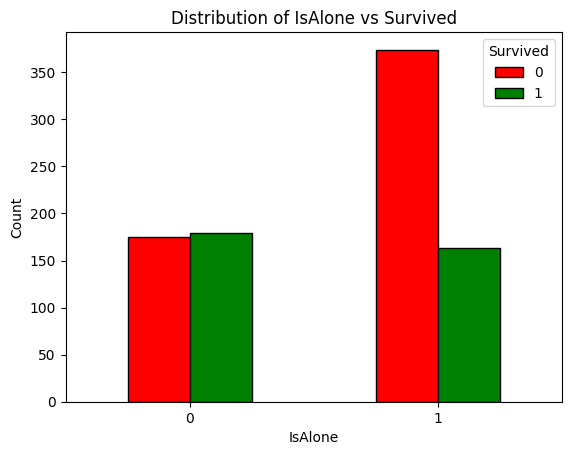

In [119]:
counts = titanic_df.groupby(['IsAlone', 'Survived']).size().unstack()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color=['red','green'], edgecolor='black')

plt.title('Distribution of IsAlone vs Survived')
plt.xlabel('IsAlone')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

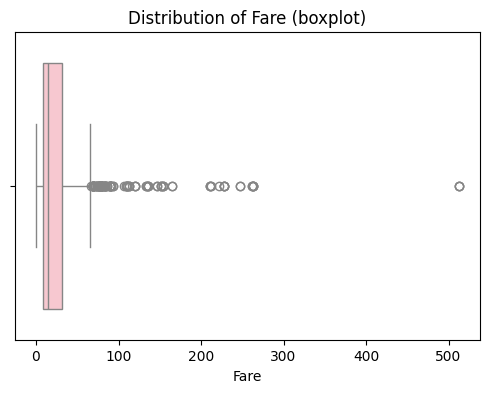

In [120]:
def boxplot(df, column_name):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='pink') 
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)

    plt.show()


boxplot (titanic_df,'Fare')

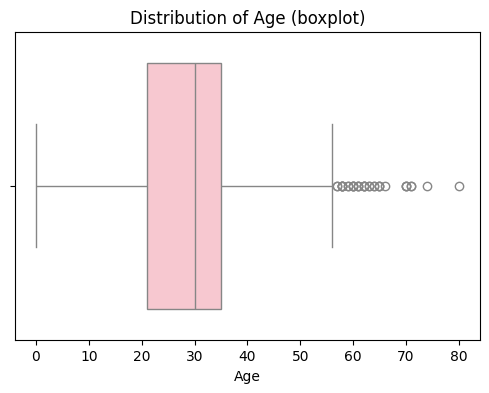

In [121]:
boxplot (titanic_df,'Age')

# 5. Kodowanie zmiennych kategorialnych

In [122]:
titanic_df['Sex'] = titanic_df.Sex.map({ 'male': 0 , 'female' :1})

titanic_df = titanic_df.drop(columns=['Title'])

one_hot_encoded_columns = ['Embarked']
titanic_df = pd.get_dummies(data=titanic_df,prefix = one_hot_encoded_columns,columns = one_hot_encoded_columns,dtype=np.int32)

titanic_df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,IsCabin,IsAlone,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,0,22,1,0,7.2500,0,0,0,0,1
2,1,1,1,38,1,0,71.2833,1,0,1,0,0
3,1,3,1,26,0,0,7.9250,0,1,0,0,1
4,1,1,1,35,1,0,53.1000,1,0,0,0,1
5,0,3,0,35,0,0,8.0500,0,1,0,0,1
6,0,3,0,30,0,0,8.4583,0,1,0,1,0
7,0,1,0,54,0,0,51.8625,1,1,0,0,1
8,0,3,0,2,3,1,21.0750,0,0,0,0,1
9,1,3,1,27,0,2,8.0500,0,0,0,0,1


In [123]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

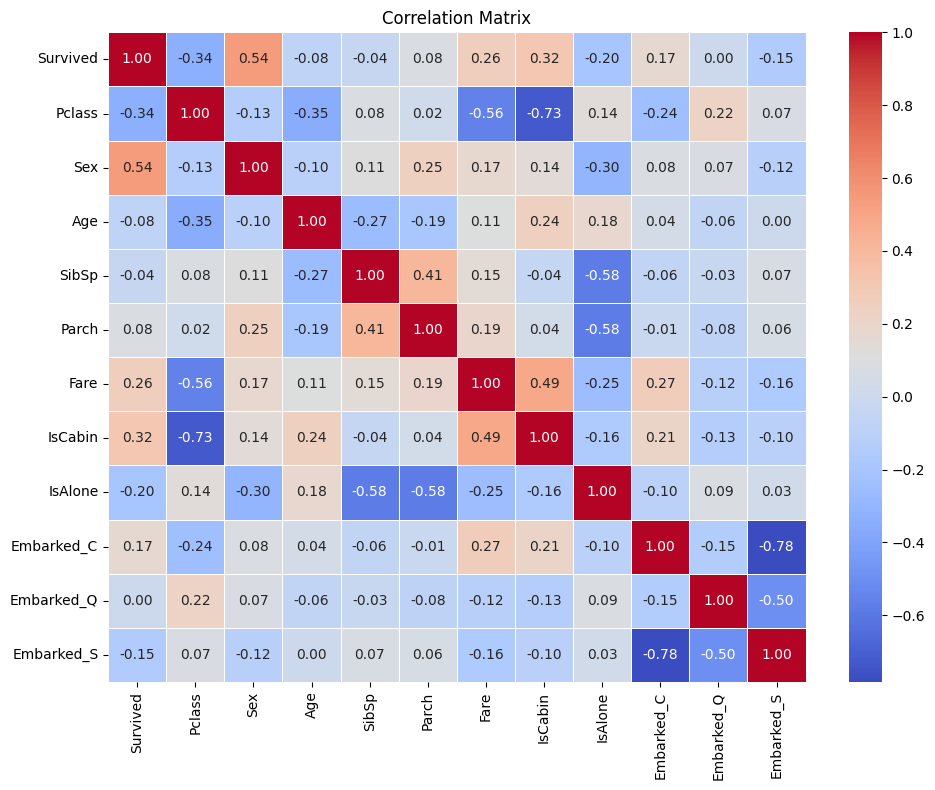

In [124]:

def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(titanic_df)

In [125]:
titanic_df.to_csv('titanic_processed.csv')